# SmolVLA Attention Visualization

不改动 lerobot 源码，通过一行 monkey-patch 捕获 SmolVLA 前向推理中的所有 attention map。

## Step 0: 环境准备

依赖: `visualizer`（本项目自带）, `lerobot[smolvla]`, `torch`, `matplotlib`, `numpy`。

如未安装 lerobot: `pip install -e ".[smolvla]"`（在 lerobot 仓库根目录执行）。

## Step 1: 激活 get_local 并导入基础依赖

In [1]:
import ssl
import certifi

_orig_create_default_context = ssl.create_default_context
def _patched_create_default_context(purpose=ssl.Purpose.SERVER_AUTH, *, cafile=None, capath=None, cadata=None):
    ctx = ssl.SSLContext(ssl.PROTOCOL_TLS_CLIENT)
    ctx.load_verify_locations(cafile=certifi.where())
    return ctx
ssl.create_default_context = _patched_create_default_context

from visualizer import get_local
get_local.activate()

import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image

print(f"get_local activated: {get_local.is_activate}")
print(f"PyTorch {torch.__version__}, CUDA {torch.cuda.is_available()}")

get_local activated: True
PyTorch 2.7.1+cu126, CUDA True


## Step 2: 加载模型 & 预处理器

In [2]:
from lerobot.policies.smolvla.modeling_smolvla import SmolVLAPolicy
from lerobot.policies.factory import make_pre_post_processors

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

policy = SmolVLAPolicy.from_pretrained(r"D:\CodeProject\ModelTrainRepo\Checkpoint\pick_pen_give_human\smolvla\checkpoints\020000\pretrained_model")
policy.to(device)
policy.eval()

preprocessor, postprocessor = make_pre_post_processors(
    policy_cfg=policy.config,
    pretrained_path=r"D:\CodeProject\ModelTrainRepo\Checkpoint\pick_pen_give_human\smolvla\checkpoints\020000\pretrained_model",
    preprocessor_overrides={"device_processor": {"device": str(device)}},
)

model = policy.model.vlm_with_expert
print(f"num_vlm_layers: {model.num_vlm_layers}")
print(f"self_attn_every_n_layers: {model.self_attn_every_n_layers}")
print(f"num_expert_layers: {model.num_expert_layers}")

Loading  HuggingFaceTB/SmolVLM2-500M-Video-Instruct weights ...


`torch_dtype` is deprecated! Use `dtype` instead!


Reducing the number of VLM layers to 16 ...
Loading weights from local directory
num_vlm_layers: 16
self_attn_every_n_layers: 2
num_expert_layers: 16


## Step 3: Monkey-patch

用 `get_local('probs')` 包装 `eager_attention_forward`。wrapper 会改写字节码使其返回 `(att_output, probs)` 元组，拆包后 `probs` 存入 cache，`att_output` 原样透传。

In [3]:
import types

model.eager_attention_forward = types.MethodType(
    get_local('probs')(model.eager_attention_forward.__func__),
    model
)
print("monkey-patch done")

monkey-patch done


## Step 4: 辅助函数

所有层的 attention 汇聚到同一个 `eager_attention_forward`，cache 是 flat list。下面两个函数负责标注层号/类型和输出概览。

In [4]:
def annotate_smolvla_cache(cache_list, num_vlm_layers=16, self_attn_every_n=2):
    """
    两阶段解析 flat list 的 attention maps。

    Phase 1 (fill_kv_cache=True): 前 num_vlm_layers 条, 全部 self_attn, shape (H, Lp, Lp)
    Phase 2 (denoise_step × 10): 每步 num_vlm_layers 条,
      - 偶数层 (layer_idx % every_n == 0): self_attn,   shape (H, La, Lp+La)
      - 奇数层:                            expert_cross, shape (H, La, Lp)

    Returns: list[dict], 每条 {layer_idx, type, phase, step, probs}
    """
    annotated = []
    remaining = list(cache_list)
    total = len(remaining)

    # --- Phase 1 ---
    for layer_idx in range(num_vlm_layers):
        if remaining:
            annotated.append({
                "layer_idx": layer_idx,
                "type": "self_attn",
                "phase": 1,
                "step": None,
                "probs": remaining.pop(0),
            })

    # --- Phase 2 ---
    step = 0
    while remaining:
        for layer_idx in range(num_vlm_layers):
            if not remaining:
                break
            probs = remaining.pop(0)
            if layer_idx % self_attn_every_n == 0:
                atype = "self_attn"
            else:
                atype = "expert_cross_attn"
            annotated.append({
                "layer_idx": layer_idx,
                "type": atype,
                "phase": 2,
                "step": step,
                "probs": probs,
            })
        step += 1

    return annotated


def summarize_cache(cache):
    """打印两阶段 cache 概要"""
    from collections import Counter, defaultdict

    p1 = [e for e in cache if e["phase"] == 1]
    p2 = [e for e in cache if e["phase"] == 2]

    print(f"=== Cache Summary ===")
    print(f"Total entries: {len(cache)}")
    print(f"  Phase 1 (KV cache): {len(p1)}")
    print(f"  Phase 2 (denoise):  {len(p2)}")

    # Phase 1 shape
    if p1:
        s = p1[0]["probs"].shape
        print(f"  Phase 1 shape: (H={s[0]}, Lq={s[1]}, Lk={s[2]})  # prefix self-attn")
        t1 = Counter(e["type"] for e in p1)
        print(f"  Phase 1 types: {dict(t1)}")

    # Phase 2
    if p2:
        steps = sorted(set(e["step"] for e in p2))
        print(f"  Phase 2 steps: {steps}")
        by_step = defaultdict(lambda: defaultdict(list))
        for e in p2:
            by_step[e["step"]][e["type"]].append(e)

        for step in steps[:2]:  # 只展示前 2 步的详情
            sd = by_step[step]
            sa = sd.get("self_attn", [])
            xa = sd.get("expert_cross_attn", [])
            shape_sa = sa[0]["probs"].shape if sa else "N/A"
            shape_xa = xa[0]["probs"].shape if xa else "N/A"
            print(f"    step {step}: self_attn={len(sa)}×{shape_sa}, expert_cross={len(xa)}×{shape_xa}")
        if len(steps) > 2:
            print(f"    ... ({len(steps)} steps total)")

    # 样例
    print(f"\n  Sample entries:")
    for e in cache[:2]:
        extra = f"step={e['step']}" if e['phase'] == 2 else ""
        print(f"    phase={e['phase']} layer={e['layer_idx']:2d}  "
              f"type={e['type']:20s}  shape={e['probs'].shape}  {extra}")

print("helper functions defined")

helper functions defined


---
## 路径 A: 从 LeRobot 数据集加载真实数据

适用于实际分析 —— 真实的图片、语言指令和机器人状态。

### A1: 加载数据集

In [5]:
from lerobot.datasets.lerobot_dataset import LeRobotDataset, LeRobotDatasetMetadata
from lerobot.datasets.factory import resolve_delta_timestamps

# TODO: 替换为实际 repo，例如:
#   "danaaubakirova/svla_so100_task1_v3"
#   "lerobot/aloha_sim_insertion_human"
DATASET_REPO = r"D:\Huggingface Cache\lerobot\CozyFire\pick_pen_give_human"

ds_meta = LeRobotDatasetMetadata(DATASET_REPO)
delta_timestamps = resolve_delta_timestamps(policy.config, ds_meta)
dataset = LeRobotDataset(DATASET_REPO, delta_timestamps=delta_timestamps)

print(f"Dataset: {DATASET_REPO}")
print(f"Frames: {dataset.num_frames}")
print(f"Episodes: {dataset.num_episodes}")
print(f"Camera keys: {[k for k in dataset[0].keys() if 'image' in k]}")

Dataset: D:\Huggingface Cache\lerobot\CozyFire\pick_pen_give_human
Frames: 34506
Episodes: 50


D:\conda\envs\lerobot\lib\site-packages\torchvision\io\_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


Camera keys: ['observation.images.wrist', 'observation.images.wrist_is_pad']


### A2: 取一条数据 → 预处理 → forward

In [6]:
get_local.clear()

item = dataset[0]

print("Raw item keys:", list(item.keys()))
print(f"  observation.state: {item['observation.state'].shape}")
for k in item:
    if 'image' in k:
        print(f"  {k}: {item[k].shape}")
print(f"  task: {item.get('task', 'N/A')!r}")
if 'action' in item:
    print(f"  action: {item['action'].shape}")

Raw item keys: ['observation.images.wrist', 'action', 'observation.state', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index', 'action_is_pad', 'observation.state_is_pad', 'observation.images.wrist_is_pad', 'task']
  observation.state: torch.Size([1, 6])
  observation.images.wrist: torch.Size([3, 480, 640])
  observation.images.wrist_is_pad: torch.Size([1])
  task: '拿起笔，递给面前的人'
  action: torch.Size([50, 6])


In [7]:
batch = preprocessor(item)

print("Preprocessed batch keys:", list(batch.keys()))
print(f"  observation.state:                   {batch['observation.state'].shape}")
print(f"  observation.language.tokens:         {batch['observation.language.tokens'].shape}")
print(f"  observation.language.attention_mask: {batch['observation.language.attention_mask'].shape}")

Preprocessed batch keys: ['action', 'next.reward', 'next.done', 'next.truncated', 'info', 'action_is_pad', 'observation.state_is_pad', 'observation.images.wrist_is_pad', 'task', 'index', 'task_index', 'episode_index', 'observation.images.camera1', 'observation.state', 'observation.language.tokens', 'observation.language.attention_mask']
  observation.state:                   torch.Size([1, 6])
  observation.language.tokens:         torch.Size([1, 48])
  observation.language.attention_mask: torch.Size([1, 48])


In [8]:
with torch.no_grad():
    action_chunk = policy.predict_action_chunk(batch)

print(f"Predicted action chunk: {action_chunk.shape}")

probs_list = get_local.cache['SmolVLMWithExpertModel.eager_attention_forward']
print(f"eager_attention_forward calls: {len(probs_list)}")

Predicted action chunk: torch.Size([1, 50, 6])
eager_attention_forward calls: 176


In [9]:
cache = annotate_smolvla_cache(probs_list, model.num_vlm_layers, model.self_attn_every_n_layers)
summarize_cache(cache)

=== Cache Summary ===
Total entries: 176
  Phase 1 (KV cache): 16
  Phase 2 (denoise):  160
  Phase 1 shape: (H=1, Lq=15, Lk=113)  # prefix self-attn
  Phase 1 types: {'self_attn': 16}
  Phase 2 steps: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
    step 0: self_attn=8×(1, 15, 50, 163), expert_cross=8×(1, 15, 50, 113)
    step 1: self_attn=8×(1, 15, 50, 163), expert_cross=8×(1, 15, 50, 113)
    ... (10 steps total)

  Sample entries:
    phase=1 layer= 0  type=self_attn             shape=(1, 15, 113, 113)  
    phase=1 layer= 1  type=self_attn             shape=(1, 15, 113, 113)  


---
## 路径 B: 构造假数据快速验证

不需要真实数据集，构造随机数据验证 monkey-patch 链路是否打通。适合首次排查。

### B1: 构造假 batch → forward

In [10]:
# get_local.clear()
#
# # 从 config 获取 image feature 的信息（key 名和 shape）
# img_key = list(policy.config.image_features.keys())[0]
# img_shape = policy.config.image_features[img_key].shape
#
# # 从预处理器获取实际 state 维度
# state_dim = preprocessor.steps[5].stats["observation.state"]["mean"].shape[0]
#
# fake_item = {
#     "observation.state": torch.randn(state_dim, dtype=torch.float32),
#     img_key: torch.rand(*img_shape, dtype=torch.float32),
#     "task": "pick the red block\n",
# }
#
# batch = preprocessor(fake_item)
#
# print("Fake batch keys:", list(batch.keys()))
# for k, v in batch.items():
#     if isinstance(v, torch.Tensor):
#         print(f"  {k}: {v.shape}  dtype={v.dtype}  device={v.device}")

In [11]:
# with torch.no_grad():
#     action_chunk = policy.predict_action_chunk(batch)
#
# probs_list = get_local.cache['SmolVLMWithExpertModel.eager_attention_forward']
# print(f"\n捕获到 {len(probs_list)} 个 attention maps")
#
# if len(probs_list) >= 24:
#     print("monkey-patch 生效，链路通畅!")
# else:
#     print("数量异常，请检查 activate()/clear() 是否在正确位置执行")

In [12]:
# cache = annotate_smolvla_cache(probs_list, model.num_vlm_layers, model.self_attn_every_n_layers)
# summarize_cache(cache)

---

## Step 5: Phase 2 可视化

仅关注去噪阶段（denoise_step）的注意力变化。以下所有函数仅使用 `phase=2` 的 cache 条目。

### 5.1 同 Step 所有 Layer

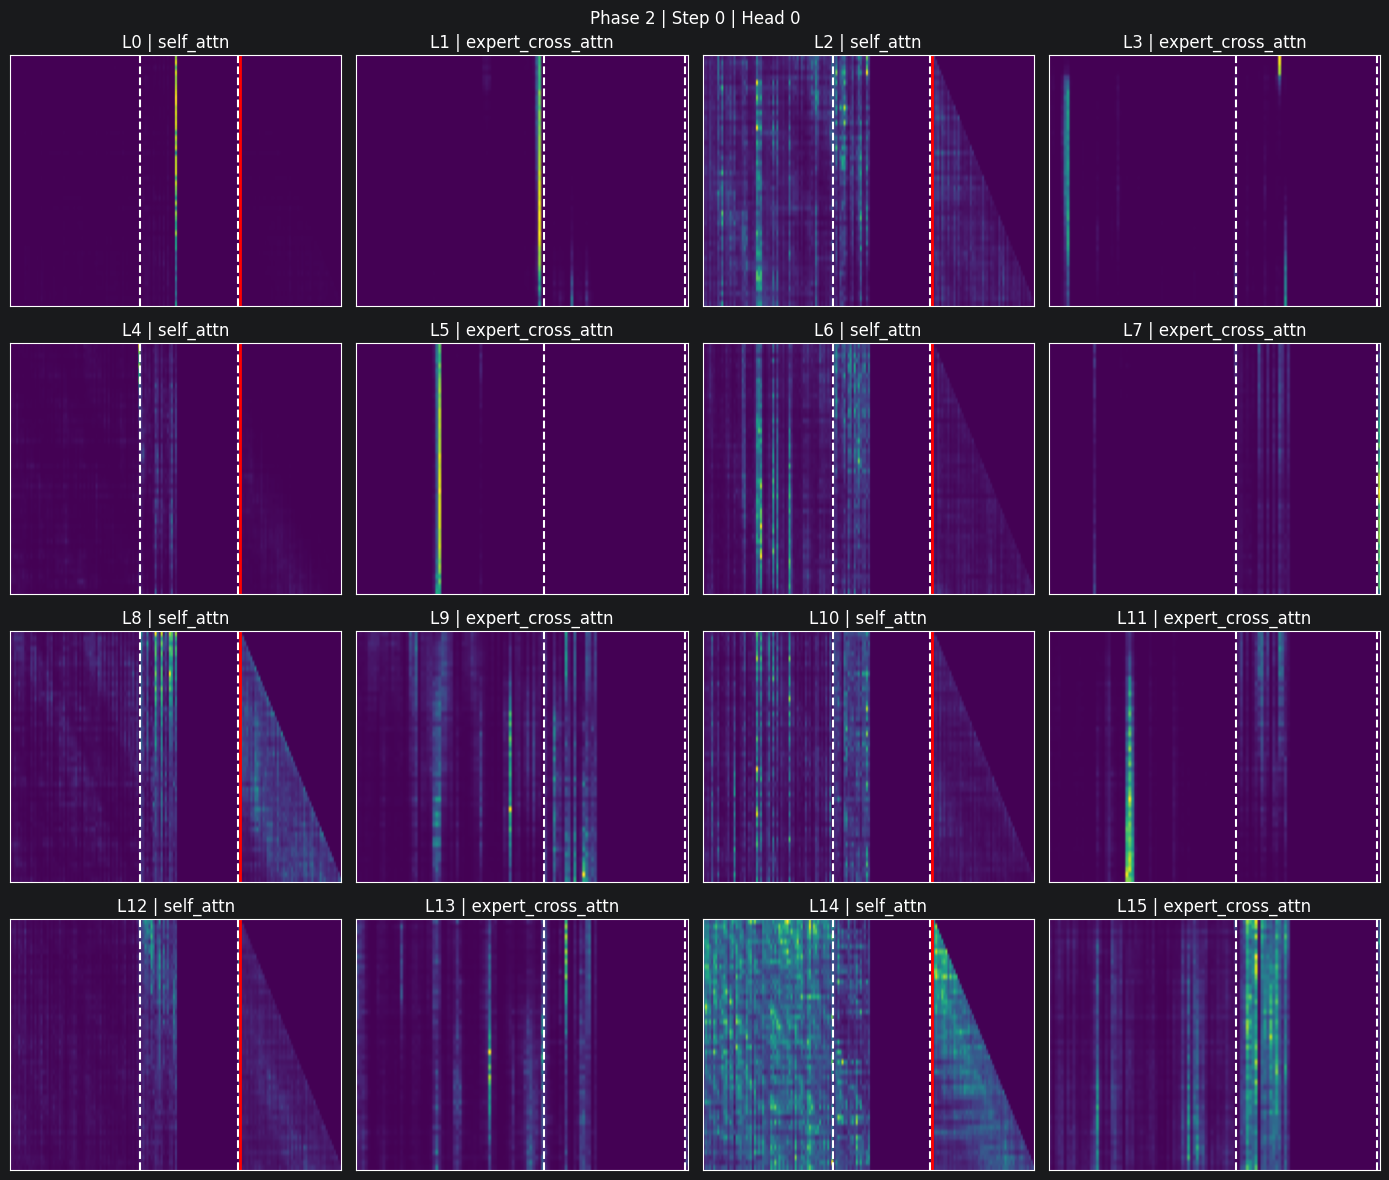

In [13]:
# ── 分区常量 ──
IMG       = 64    # image patches
LANG      = 48    # language tokens
STATE     = 1     # state token
ACTION    = 50    # action tokens (suffix)
IMG_END   = IMG
LANG_END  = IMG + LANG         # 112
PREFIX_END = IMG + LANG + STATE  # 113


def draw_partitions(ax, entry):
    """在 attention 热力图上画 K 轴分区线。"""
    is_self = (entry["type"] == "self_attn")
    kw_img  = dict(color='white', linewidth=1.5, linestyle='--')
    kw_pref = dict(color='red', linewidth=2.0, linestyle='-')

    ax.axvline(IMG_END - 0.5, **kw_img)
    ax.axvline(LANG_END - 0.5, **kw_img)
    if is_self:
        ax.axvline(PREFIX_END - 0.5, **kw_pref)


def vis_step_layers(cache, step, head_idx=0):
    """同一 step 下所有 layer 的同一 head 注意力。"""
    entries = [e for e in cache
               if e["phase"] == 2 and e["step"] == step]
    entries.sort(key=lambda e: e["layer_idx"])
    if not entries:
        print(f"No Phase2 entries for step={step}")
        return

    cols = 4
    rows = (len(entries) - 1) // cols + 1
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3))

    for i, entry in enumerate(entries):
        ax = axes[i // cols][i % cols] if rows > 1 else axes[i % cols]
        p = entry["probs"][0, head_idx]  # (Lq, Lk)
        ax.imshow(p, cmap='viridis', aspect='auto')
        draw_partitions(ax, entry)
        ax.set_title(f"L{entry['layer_idx']} | {entry['type']}")
        ax.set_xticks([]); ax.set_yticks([])

    for j in range(len(entries), rows * cols):
        ax = axes[j // cols][j % cols] if rows > 1 else axes[j % cols]
        ax.axis('off')

    fig.suptitle(f"Phase 2 | Step {step} | Head {head_idx}")
    plt.tight_layout()
    plt.show()


vis_step_layers(cache, step=0, head_idx=0)

### 5.2 同 Step 单 Layer 全部 Head

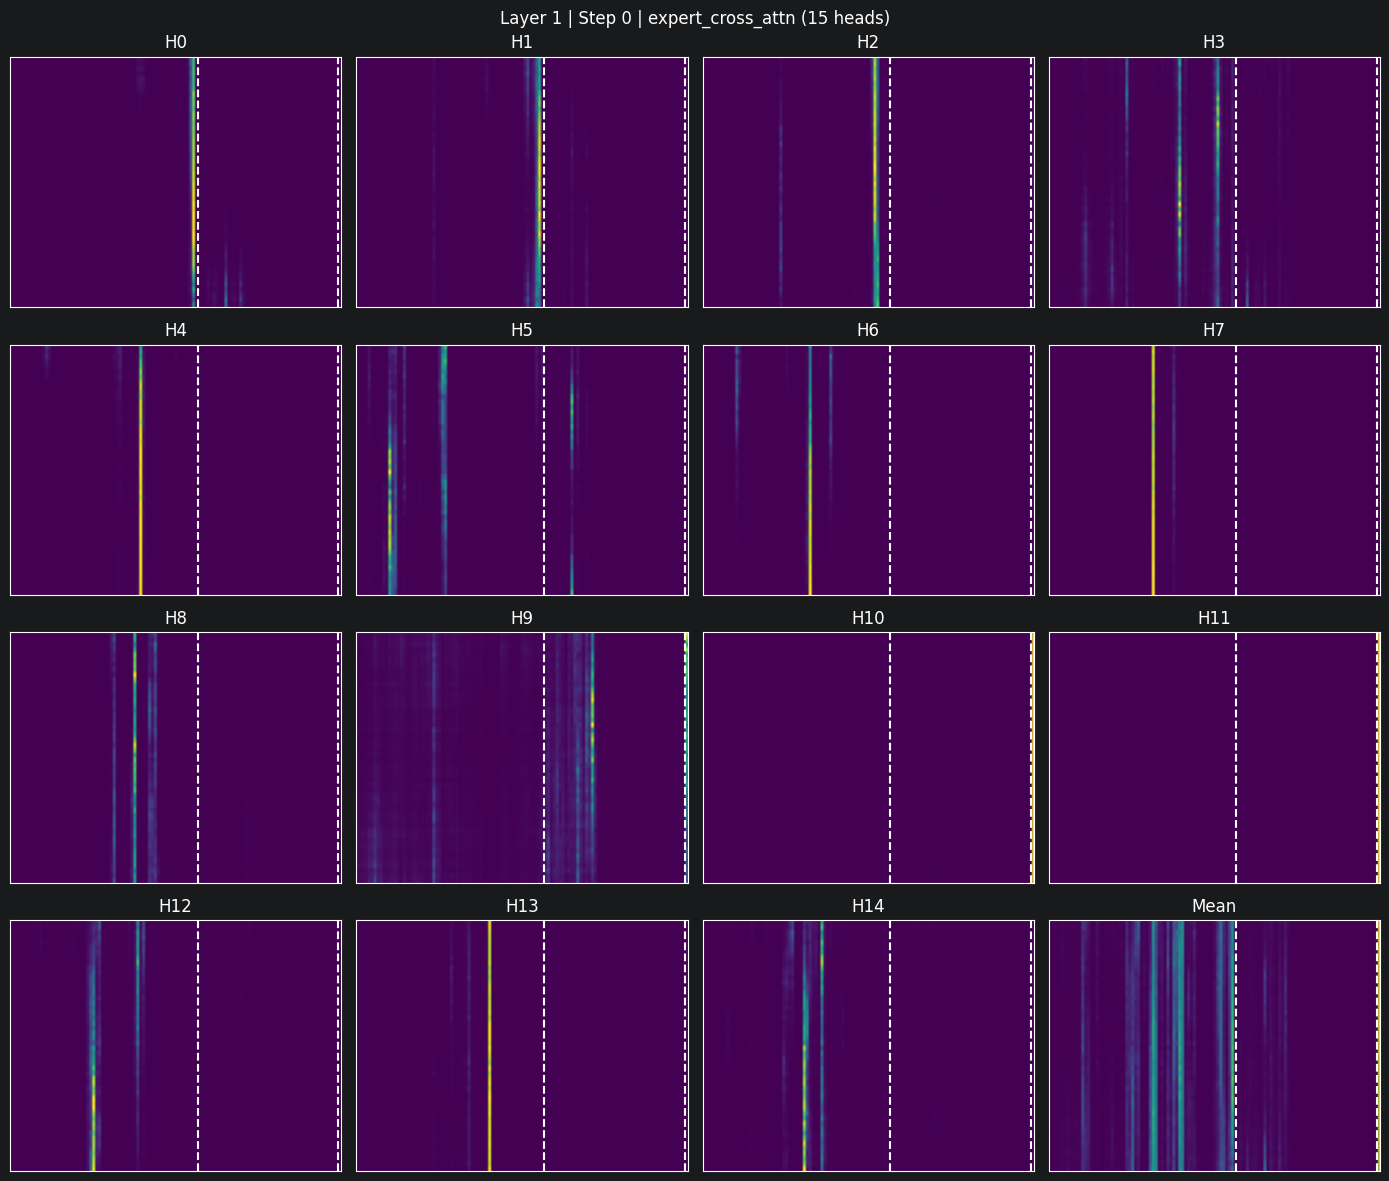

In [14]:
def vis_step_layer_heads(cache, step, layer_idx):
    """同一 step 下单个 layer 的全部 head。"""
    entries = [e for e in cache
               if e["phase"] == 2 and e["step"] == step and e["layer_idx"] == layer_idx]
    if not entries:
        print(f"No Phase2 entry for step={step} layer={layer_idx}")
        return
    entry = entries[0]

    probs = entry["probs"][0]       # (H, Lq, Lk)
    H = probs.shape[0]
    cols = min(4, H)
    rows = (H + 1 - 1) // cols + 1  # +1 for mean
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3))

    for i in range(H):
        ax = axes[i // cols][i % cols] if rows > 1 else axes[i % cols]
        ax.imshow(probs[i], cmap='viridis', aspect='auto')
        draw_partitions(ax, entry)
        ax.set_title(f"H{i}")
        ax.set_xticks([]); ax.set_yticks([])

    # Mean
    mean_idx = H
    mean_ax = axes[mean_idx // cols][mean_idx % cols] if rows > 1 else axes[mean_idx % cols]
    mean_ax.imshow(probs.mean(axis=0), cmap='viridis', aspect='auto')
    draw_partitions(mean_ax, entry)
    mean_ax.set_title("Mean")
    mean_ax.set_xticks([]); mean_ax.set_yticks([])

    for j in range(mean_idx + 1, rows * cols):
        ax = axes[j // cols][j % cols] if rows > 1 else axes[j % cols]
        ax.axis('off')

    fig.suptitle(f"Layer {layer_idx} | Step {step} | {entry['type']} ({H} heads)")
    plt.tight_layout()
    plt.show()


vis_step_layer_heads(cache, step=0, layer_idx=1)

### 5.3 跨 Step 单 Layer 单 Head

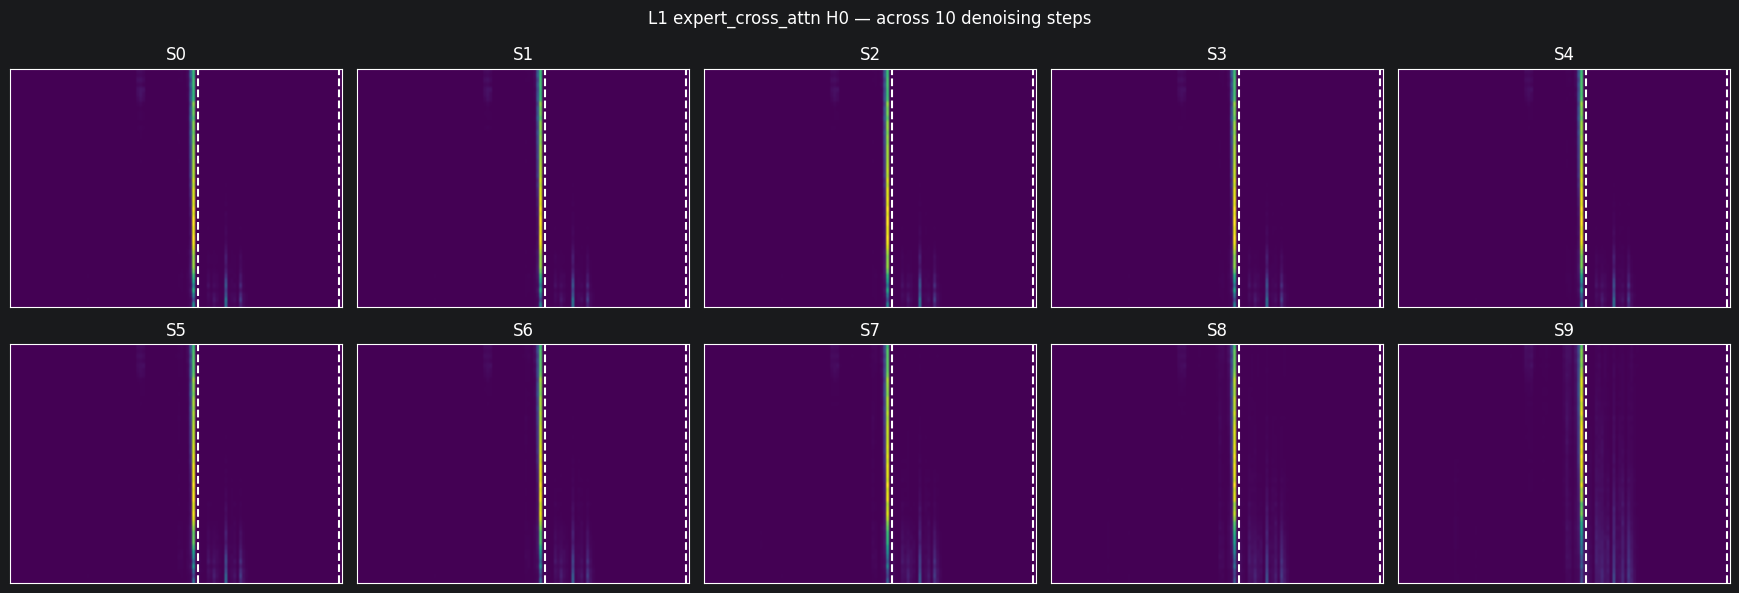

In [15]:
def vis_across_steps(cache, layer_idx, attn_type, head_idx=0):
    """单个 layer 的单个 head 在 10 个去噪步骤中的注意力演变。"""
    entries = [e for e in cache
               if e["phase"] == 2 and e["layer_idx"] == layer_idx and e["type"] == attn_type]
    entries.sort(key=lambda e: e["step"])
    if not entries:
        print(f"No entries for layer={layer_idx} type={attn_type}")
        return

    cols = 5
    rows = 2
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3))

    for i, entry in enumerate(entries):
        ax = axes[i // cols][i % cols] if rows > 1 else axes[i % cols]
        p = entry["probs"][0, head_idx]
        ax.imshow(p, cmap='viridis', aspect='auto')
        draw_partitions(ax, entry)
        ax.set_title(f"S{entry['step']}")
        ax.set_xticks([]); ax.set_yticks([])

    for j in range(len(entries), rows * cols):
        ax = axes[j // cols][j % cols] if rows > 1 else axes[j % cols]
        ax.axis('off')

    fig.suptitle(f"L{layer_idx} {attn_type} H{head_idx} — across 10 denoising steps")
    plt.tight_layout()
    plt.show()


vis_across_steps(cache, layer_idx=1, attn_type="expert_cross_attn", head_idx=0)

### 5.4 动态动画

In [16]:
def vis_animate(cache, attn_type, head_idx=0, mode="steps", fixed_layer=15):
    """
    动态动画展示注意力变化。

    mode="steps":  固定 layer，逐 step 动画（看去噪过程演变）
    mode="layers": 固定 step=0，逐 layer 动画（看深度变化）
    """
    from matplotlib.animation import FuncAnimation
    from IPython.display import HTML

    if mode == "steps":
        entries = [e for e in cache
                   if e["phase"] == 2 and e["type"] == attn_type
                   and e["layer_idx"] == fixed_layer]
        entries.sort(key=lambda e: e["step"])
        title_pre = f"L{fixed_layer} {attn_type} H{head_idx}"

    elif mode == "layers":
        entries = [e for e in cache
                   if e["phase"] == 2 and e["type"] == attn_type
                   and e["step"] == 0]
        entries.sort(key=lambda e: e["layer_idx"])
        title_pre = f"{attn_type} Step0 H{head_idx}"

    else:
        print(f"Unknown mode: {mode}")
        return

    if not entries:
        print("No matching entries")
        return

    fig, ax = plt.subplots(figsize=(7, 6))
    plt.close()  # 防止重复渲染

    def update(frame):
        ax.clear()
        entry = entries[frame]
        p = entry["probs"][0, head_idx]
        ax.imshow(p, cmap='viridis', aspect='auto')
        draw_partitions(ax, entry)
        if mode == "steps":
            ax.set_title(f"{title_pre} | Step {entry['step']}")
        else:
            ax.set_title(f"{title_pre} | Layer {entry['layer_idx']}")
        ax.set_xticks([]); ax.set_yticks([])

    anim = FuncAnimation(fig, update, frames=len(entries), interval=600, repeat=True)
    return HTML(anim.to_jshtml())


# 示例: 看 layer 15 的 expert_cross_attn 去噪过程
vis_animate(cache, "expert_cross_attn", head_idx=0, mode="layers", fixed_layer=15)

### 5.5 叠加到原图（仅路径 A）

In [17]:
def vis_overlay_animate(cache, item, mode="steps", fixed_layer=15, fixed_step=0, head_idx=0):
    """
    动态动画：action→image 注意力叠加到原图上。

    mode="steps":  固定 layer，逐 step 动画（看去噪过程演变）
    mode="layers": 固定 step，逐 layer 动画（看深度变化）
    仅路径 A 可用。
    """
    from matplotlib.animation import FuncAnimation
    from IPython.display import HTML
    import torch.nn.functional as F

    if mode == "steps":
        entries = [e for e in cache
                   if e["phase"] == 2 and e["type"] == "expert_cross_attn"
                   and e["layer_idx"] == fixed_layer]
        entries.sort(key=lambda e: e["step"])
        title_pre = f"L{fixed_layer} H{head_idx}"

    elif mode == "layers":
        entries = [e for e in cache
                   if e["phase"] == 2 and e["type"] == "expert_cross_attn"
                   and e["step"] == fixed_step]
        entries.sort(key=lambda e: e["layer_idx"])
        title_pre = f"Step{fixed_step} H{head_idx}"

    else:
        print(f"Unknown mode: {mode}")
        return

    if not entries:
        print("No matching entries")
        return

    # 准备原图
    image_key = [k for k in item if 'image' in k][0]
    img_tensor = item[image_key]
    if isinstance(img_tensor, torch.Tensor):
        img = img_tensor.permute(1, 2, 0).cpu().numpy()
    else:
        img = np.array(img_tensor)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    img = (img * 255).astype(np.uint8)

    fig, ax = plt.subplots(figsize=(6, 6))
    plt.close()

    def update(frame):
        ax.clear()
        entry = entries[frame]
        probs = entry["probs"][0, head_idx]          # (50, 113)
        att_to_image = probs[:, :IMG]                 # (50, 64)
        avg_att = att_to_image.mean(axis=0)           # (64,)
        heatmap = avg_att.reshape(8, 8)

        hmap_t = torch.tensor(heatmap, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        hmap_up = F.interpolate(hmap_t, size=img.shape[:2], mode='bilinear').squeeze().numpy()
        hmap_up = (hmap_up - hmap_up.min()) / (hmap_up.max() - hmap_up.min() + 1e-8)

        ax.imshow(img)
        ax.imshow(hmap_up, cmap='jet', alpha=0.5)

        if mode == "steps":
            ax.set_title(f"{title_pre} | Step {entry['step']}")
        else:
            ax.set_title(f"{title_pre} | Layer {entry['layer_idx']}")
        ax.axis('off')

    anim = FuncAnimation(fig, update, frames=len(entries), interval=600, repeat=True)
    return HTML(anim.to_jshtml())


# 示例: steps 模式
vis_overlay_animate(cache, item, mode="layers", head_idx=0, fixed_step=9)

---
## Step 6: 清理

In [18]:
# get_local.clear()
# print("Cache cleared.")
# 如需彻底恢复: 重新加载模型即可